# Working Notebook - Group 8
Avalos-Morfin, Perez, Rodriguez

In [18]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules

from google.colab import drive
drive.mount('/content/drive')
save_path = '/content/drive/My Drive/ADS505A/Project/graphs'

import warnings
warnings.filterwarnings('ignore')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%%capture
def url_converter(url):
  google_download_prefix = 'https://docs.google.com/uc?export=download&id='
  file_id = url.split('/')[-2]
  return google_download_prefix + file_id

sharable_url= 'https://docs.google.com/spreadsheets/d/11fPZugwHDrjbg1mH8PdRxCfskJdWQHb0/edit?usp=drive_link&ouid=113951926179400508661&rtpof=true&sd=true'

# Get the file added to local enviroment
url = url_converter(sharable_url)
!wget --no-check-certificate "$url" -O dataframe.csv --content-disposition

path_to_file= '/content/dataframe.csv'

In [3]:
# Load data
coffee_df = pd.read_excel(path_to_file)
coffee_df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


# EDA & Basic Overview

In [4]:
# Start w/ basic EDA to give an overview of the data
print(coffee_df.info())
print(coffee_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 12.5+ MB
None
       transaction_id               transaction_date  transaction_qty  \
count   149116

In [5]:
# Check for missing values
coffee_df.isnull().sum()

,0
transaction_id,0
transaction_date,0
transaction_time,0
transaction_qty,0
store_id,0
store_location,0
product_id,0
unit_price,0
product_category,0
product_type,0


In [6]:
# Check for duplicated values
print(coffee_df.duplicated().sum())

0


# Preliminary Investigations

In [7]:
# Convert datetime formate for transaction_time
coffee_df['transaction_time'] = pd.to_datetime(coffee_df['transaction_time'], format='%H:%M:%S').dt.time

# Extract useful time features
coffee_df['hour'] = pd.to_datetime(coffee_df['transaction_time'].astype(str)).dt.hour
coffee_df['day_of_week'] = coffee_df['transaction_date'].dt.day_name()
coffee_df['month'] = coffee_df['transaction_date'].dt.month_name()

# Create a column for revenue
coffee_df['revenue'] = coffee_df['transaction_qty'] * coffee_df['unit_price']

In [8]:
# Get familiar with product types
print(f"Categories: {coffee_df['product_category'].unique()}\n")
print(f"Types: {coffee_df['product_type'].unique()}\n")
print(f"Details: {coffee_df['product_detail'].unique()}")

Categories: ['Coffee' 'Tea' 'Drinking Chocolate' 'Bakery' 'Flavours' 'Loose Tea'
 'Coffee beans' 'Packaged Chocolate' 'Branded']

Types: ['Gourmet brewed coffee' 'Brewed Chai tea' 'Hot chocolate' 'Drip coffee'
 'Scone' 'Barista Espresso' 'Brewed Black tea' 'Brewed Green tea'
 'Brewed herbal tea' 'Biscotti' 'Pastry' 'Organic brewed coffee'
 'Premium brewed coffee' 'Regular syrup' 'Herbal tea' 'Gourmet Beans'
 'Organic Beans' 'Sugar free syrup' 'Drinking Chocolate' 'Premium Beans'
 'Chai tea' 'Green beans' 'Espresso Beans' 'Green tea' 'Organic Chocolate'
 'Housewares' 'Black tea' 'House blend Beans' 'Clothing']

Details: ['Ethiopia Rg' 'Spicy Eye Opener Chai Lg' 'Dark chocolate Lg'
 'Our Old Time Diner Blend Sm' 'Oatmeal Scone' 'Columbian Medium Roast Sm'
 'Latte Rg' 'Dark chocolate Rg' 'Spicy Eye Opener Chai Rg' 'Ethiopia Lg'
 'Earl Grey Lg' 'Ouro Brasileiro shot' 'Serenity Green Tea Lg'
 'Jumbo Savory Scone' 'Lemon Grass Rg' 'Sustainably Grown Organic Lg'
 'Hazelnut Biscotti' 'Cappucci

## Sales by Hour

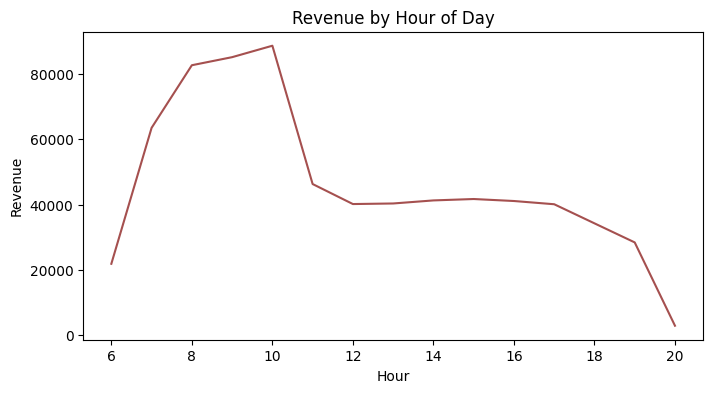

In [24]:
# Line chart - sales volume over time (hourly trends)
hourly_sales = coffee_df.groupby('hour')['revenue'].sum()
plt.figure(figsize=(8,4))
sns.lineplot(x=hourly_sales.index, y=hourly_sales.values, color='#a5504f')
plt.title('Revenue by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Revenue')
plt.savefig(f'{save_path}/revenue_by_hour_of_day.png')
plt.show()

Sales peak between 8am to 10am with a sharp decline until noon and a gradual decline after 5pm

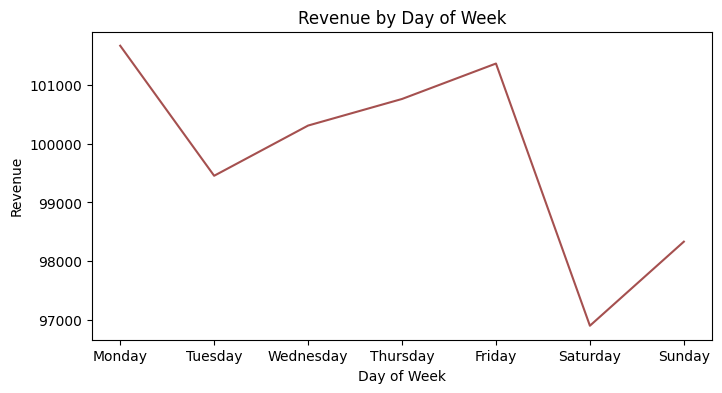

In [25]:
# Line chart - sales volume over time (weekly trends)
# Correct order of days first so it is not alphabetical
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
coffee_df['day_of_week'] = pd.Categorical(coffee_df['day_of_week'], categories=days_order, ordered=True)

day_of_week_sales = coffee_df.groupby('day_of_week')['revenue'].sum()
plt.figure(figsize=(8,4))
sns.lineplot(x=day_of_week_sales.index, y=day_of_week_sales.values, color='#a5504f')
plt.title('Revenue by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Revenue')
plt.savefig(f'{save_path}/revenue_by_day_of_week.png')
plt.show()

Sales peak on Friday and generally stay high during week days, with a sharp decline on weekends, predominantly Saturdays

## Sales by Month

In [11]:
# Determine unique values of months
month_values = coffee_df['month'].unique()
print(month_values)

['January' 'February' 'March' 'April' 'May' 'June']


*Note: there is no current data on sales for the later half of the year

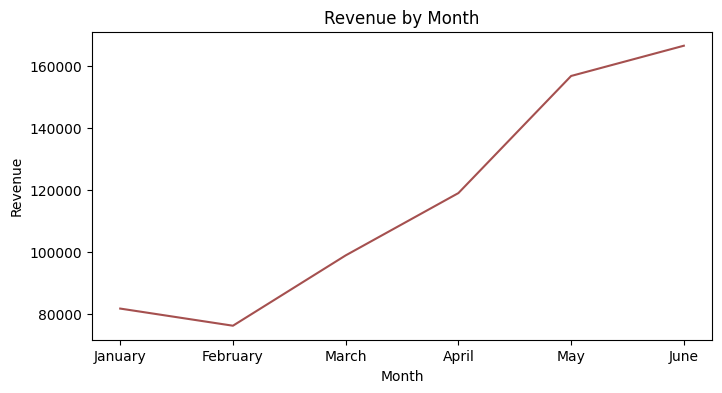

In [26]:
# Line chart - sales volume over time (monthly trends)
# Correct order of months first so it is not alphabetical
months_order = ['January', 'February', 'March', 'April', 'May', 'June']
coffee_df['month'] = pd.Categorical(coffee_df['month'], categories=months_order, ordered=True)

monthly_sales = coffee_df.groupby('month')['revenue'].sum()
plt.figure(figsize=(8,4))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, color='#a5504f')
plt.title('Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.savefig(f'{save_path}/revenue_by_month.png')
plt.show()

Sales are low at the beginning of the year and gradually increase into the warmer/Summer months with a peak in June

## Sales by Day vs Hour

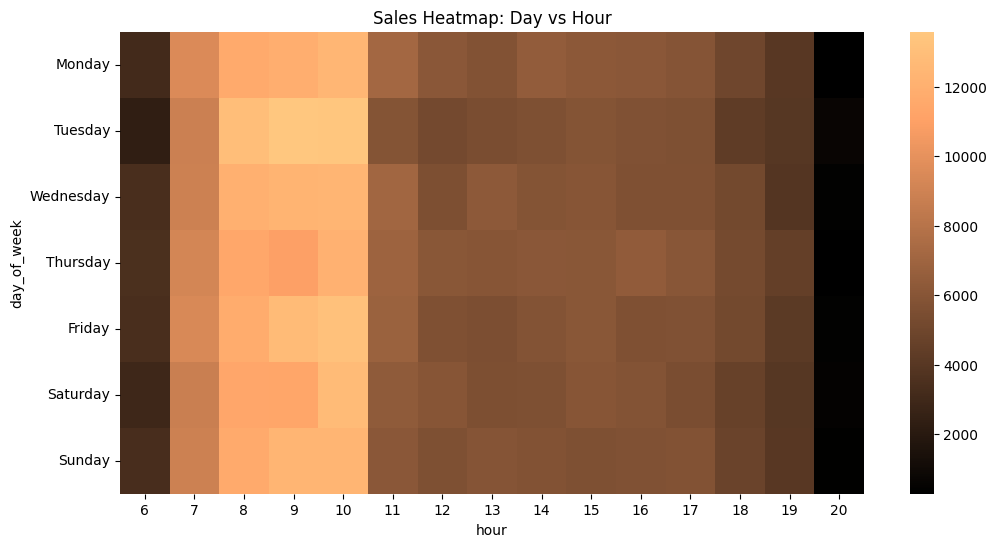

In [32]:
# Heatmap - sales by hour vs day of week... maybe could help create staffing guides
pivot = coffee_df.pivot_table(values='revenue', index='day_of_week', columns='hour', aggfunc='sum')
plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap='copper')
plt.title('Sales Heatmap: Day vs Hour')
plt.savefig(f'{save_path}/revenue_heatmap_day_vs_hour.png')
plt.show()

Stores have the most sales between the hours of 7am to 10:30am for every day of the weak, with the busiest days being Tuesday and Friday

## Best selling products and types

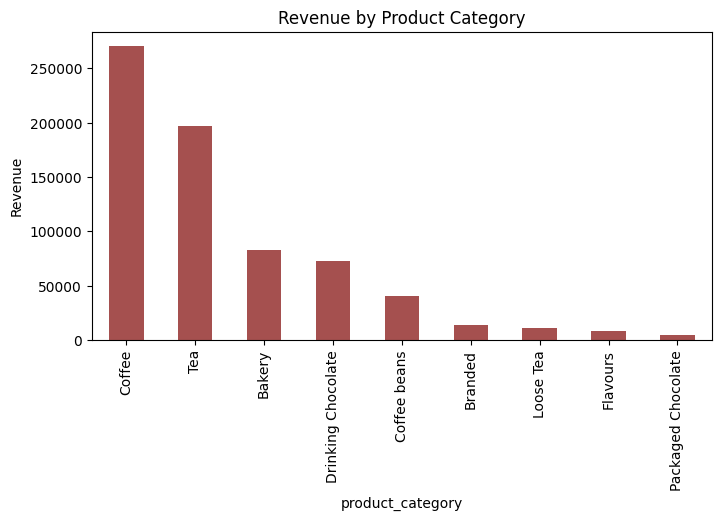

In [33]:
# Products with best sales
product_sales = coffee_df.groupby('product_category')['revenue'].sum().sort_values(ascending=False)
product_sales.plot(kind='bar', figsize=(8,4), color='#a5504f')
plt.title('Revenue by Product Category')
plt.ylabel('Revenue')
plt.savefig(f'{save_path}/revenue_by_product_category.png')
plt.show()

Not surprising - coffee is the best selling product category followed by tea, bakery, and hot chocolate. Although tea sales are still high, there is a noticeable decline in sales starting with bakery items.

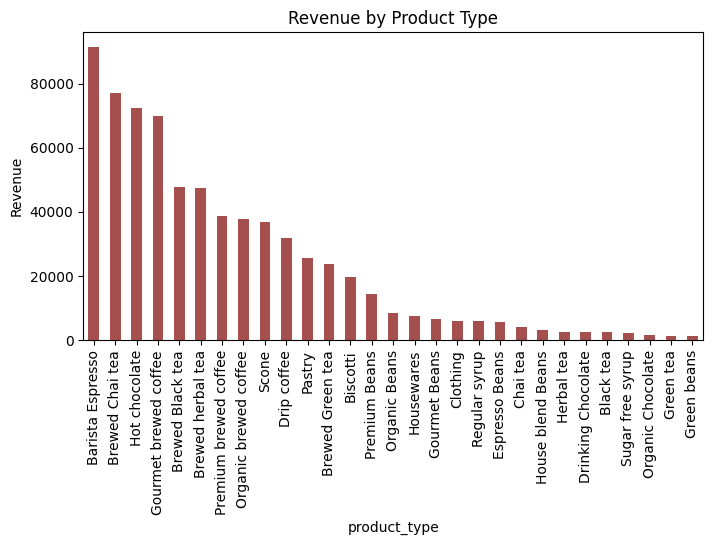

In [34]:
# Products types with best sales
product_sales = coffee_df.groupby('product_type')['revenue'].sum().sort_values(ascending=False)
product_sales.plot(kind='bar', figsize=(8,4), color='#a5504f')
plt.title('Revenue by Product Type')
plt.ylabel('Revenue')
plt.savefig(f'{save_path}/revenue_by_product_type.png')
plt.show()

Espresso products generate the most revenue, followed closely by chai, hot chocolate, and coffee. There is a noticeable drop in sales for products beyond those 4 best sellers.

## Product Trends by Month

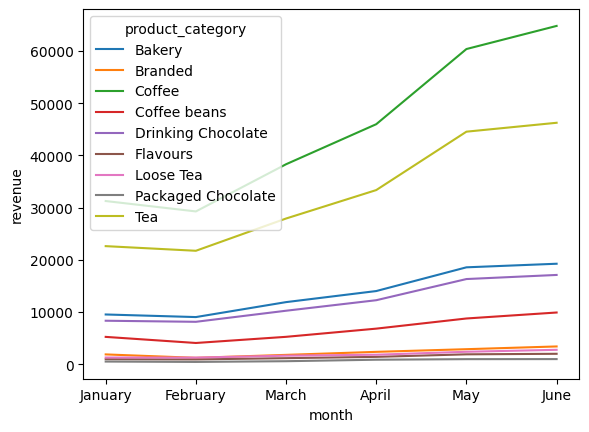

In [35]:
# Investigate any product trends that may vary by month
product_trends = coffee_df.groupby(['month','product_category'], observed=False)['revenue'].sum().reset_index()
sns.lineplot(data=product_trends, x='month', y='revenue', hue='product_category')
plt.savefig(f'{save_path}/product_trend_by_month.png')
plt.show()

Sales follow a consistent trend of gradual increase as the months go by. Cofee products sell the most regardless of month, followed by tea. All other products show significantly less revenue.

## Revenue by Location

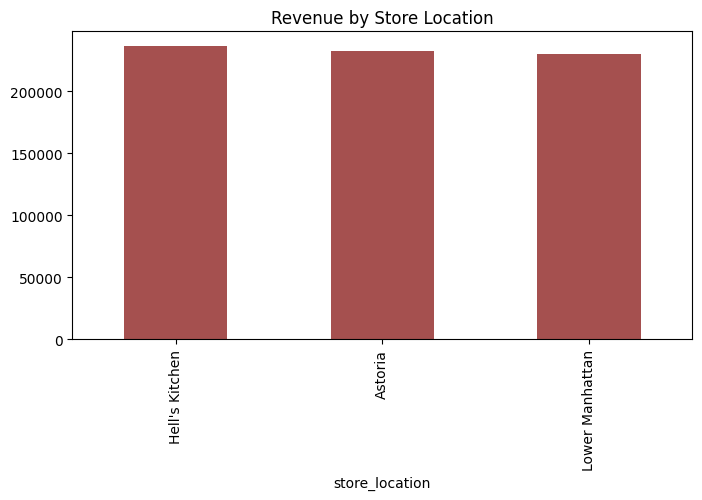

In [36]:
# Compare store performances based on revenue
store_sales = coffee_df.groupby('store_location')['revenue'].sum().sort_values(ascending=False)
store_sales.plot(kind='bar', figsize=(8,4), title='Revenue by Store Location', color='#a5504f')
plt.savefig(f'{save_path}/revenue_by_location.png')
plt.show()

No differences in store revenue. May prompt a sanity check.

# Individual Locations

In [37]:
# Let's look at findings per locations
lower_manhattan_df = coffee_df[coffee_df['store_location'] == 'Lower Manhattan'] # dark brown: #3a322f
hells_kitchen_df = coffee_df[coffee_df['store_location'] == "Hell's Kitchen"] # orange: #bf6d4d
astoria_df = coffee_df[coffee_df['store_location'] == 'Astoria'] # tan: #cebfaf

## Sales by Hour

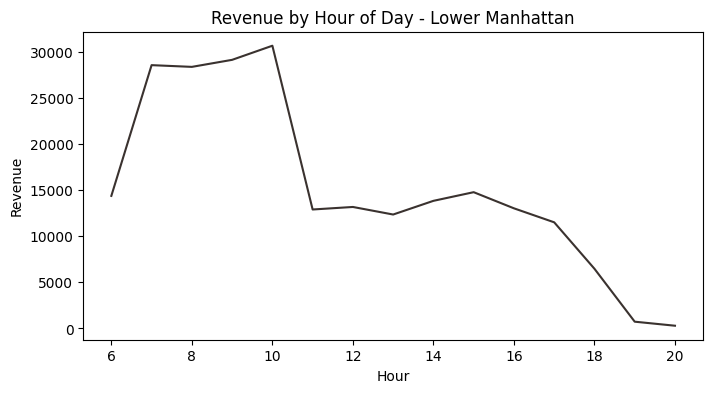

In [38]:
# Line chart - sales volume over time (hourly trends) - LOWER MANHATTAN
hourly_sales = lower_manhattan_df.groupby('hour')['revenue'].sum()
plt.figure(figsize=(8,4))
sns.lineplot(x=hourly_sales.index, y=hourly_sales.values, color='#3a322f')
plt.title('Revenue by Hour of Day - Lower Manhattan')
plt.xlabel('Hour')
plt.ylabel('Revenue')
plt.savefig(f'{save_path}/revenue_by_hour_of_day_lower_manhattan.png')
plt.show()

For Lower Manhattan, sales peak between 7am to 10am. Sharp decline until noon, with consistent sales until a gradual decrease after 4pm.

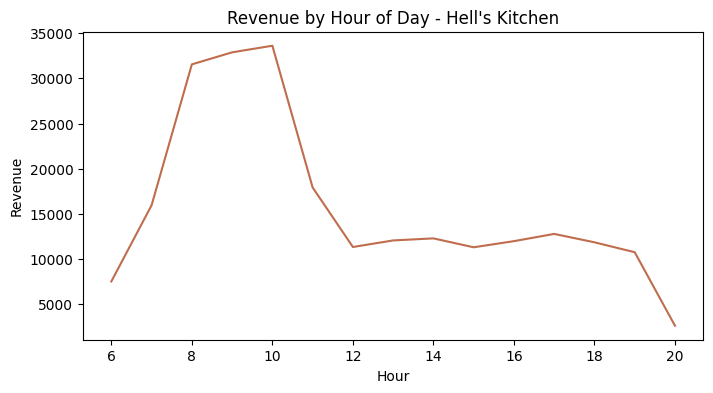

In [40]:
# Line chart - sales volume over time (hourly trends) - HELL'S KITCHEN
hourly_sales = hells_kitchen_df.groupby('hour')['revenue'].sum()
plt.figure(figsize=(8,4))
sns.lineplot(x=hourly_sales.index, y=hourly_sales.values, color='#bf6d4d')
plt.title("Revenue by Hour of Day - Hell's Kitchen")
plt.xlabel('Hour')
plt.ylabel('Revenue')
plt.savefig(f'{save_path}/revenue_by_hour_of_day_hells_kitchen.png')
plt.show()

Sales peak between 7am to 10am, with a sharp decline until noon. Sales remain consistent throughout the rest of the day with a sharp decline after 7pm.

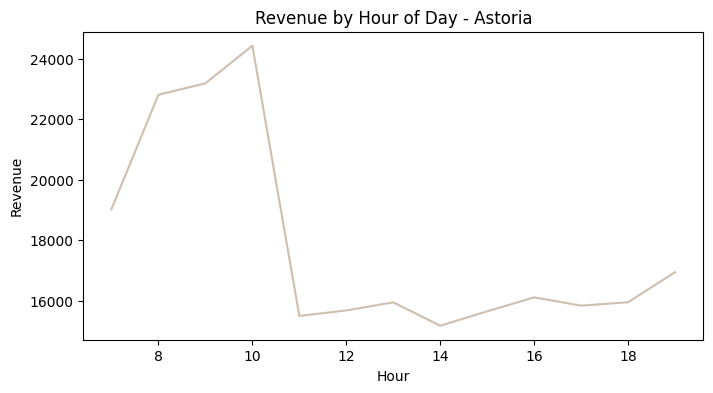

In [41]:
# Line chart - sales volume over time (hourly trends) - ASTORIA
hourly_sales = astoria_df.groupby('hour')['revenue'].sum()
plt.figure(figsize=(8,4))
sns.lineplot(x=hourly_sales.index, y=hourly_sales.values, color='#cebfaf')
plt.title('Revenue by Hour of Day - Astoria')
plt.xlabel('Hour')
plt.ylabel('Revenue')
plt.savefig(f'{save_path}/revenue_by_hour_of_day_astoria.png')
plt.show()

Peak sales at 10am with a very sharp decline until noon followed by consistent sales.

 ## Sales by Week

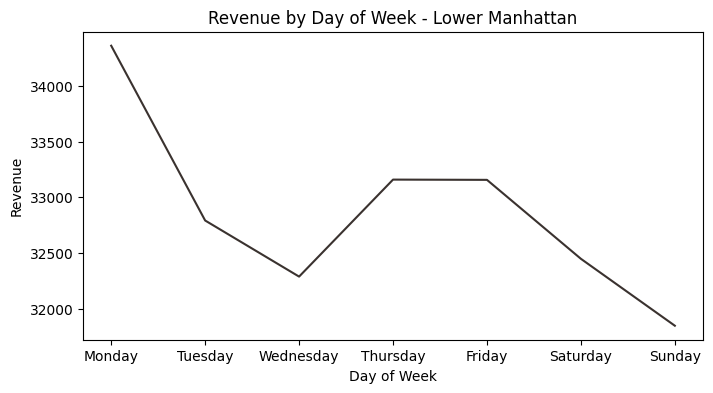

In [43]:
# Line chart - sales volume over time (weekly trends) - LOWER MANHATTAN
day_of_week_sales = lower_manhattan_df.groupby('day_of_week')['revenue'].sum()
plt.figure(figsize=(8,4))
sns.lineplot(x=day_of_week_sales.index, y=day_of_week_sales.values, color='#3a322f')
plt.title('Revenue by Day of Week - Lower Manhattan')
plt.xlabel('Day of Week')
plt.ylabel('Revenue')
plt.savefig(f'{save_path}/revenue_by_day_of_week_lower_manhattan.png')
plt.show()

Peak sales on M followed by Th and F with less revenue on T, W, Sat, Sun

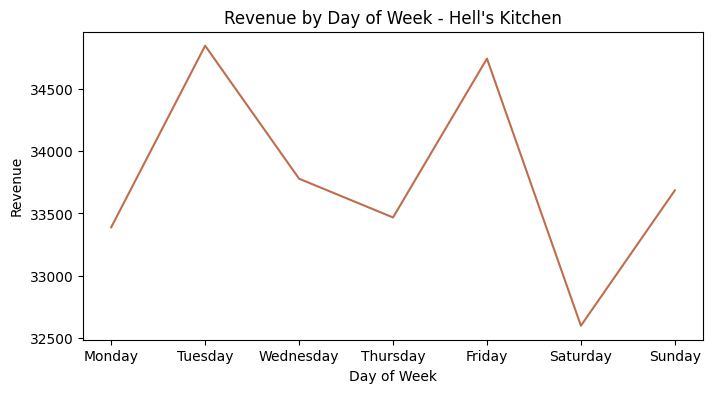

In [44]:
# Line chart - sales volume over time (weekly trends) - HELLS KITCHEN
day_of_week_sales = hells_kitchen_df.groupby('day_of_week')['revenue'].sum()
plt.figure(figsize=(8,4))
sns.lineplot(x=day_of_week_sales.index, y=day_of_week_sales.values, color='#bf6d4d')
plt.title("Revenue by Day of Week - Hell's Kitchen")
plt.xlabel('Day of Week')
plt.ylabel('Revenue')
plt.savefig(f'{save_path}/revenue_by_day_of_week_hells_kitchen.png')
plt.show()

Peak sales on T and F, less sales on M, W, Th, Sun with the lowest sales on Sat

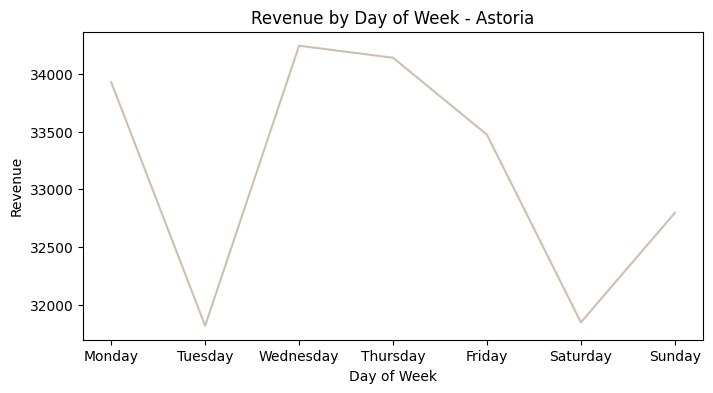

In [45]:
# Line chart - sales volume over time (weekly trends) - ASTORIA
day_of_week_sales = astoria_df.groupby('day_of_week')['revenue'].sum()
plt.figure(figsize=(8,4))
sns.lineplot(x=day_of_week_sales.index, y=day_of_week_sales.values, color='#cebfaf')
plt.title('Revenue by Day of Week - Astoria')
plt.xlabel('Day of Week')
plt.ylabel('Revenue')
plt.savefig(f'{save_path}/revenue_by_day_of_week_astoria.png')
plt.show()

Peak sales on M, W, T, with less sales on F and Sun, with the lowest sales on T, Sat

## Sales by Day vs Hour

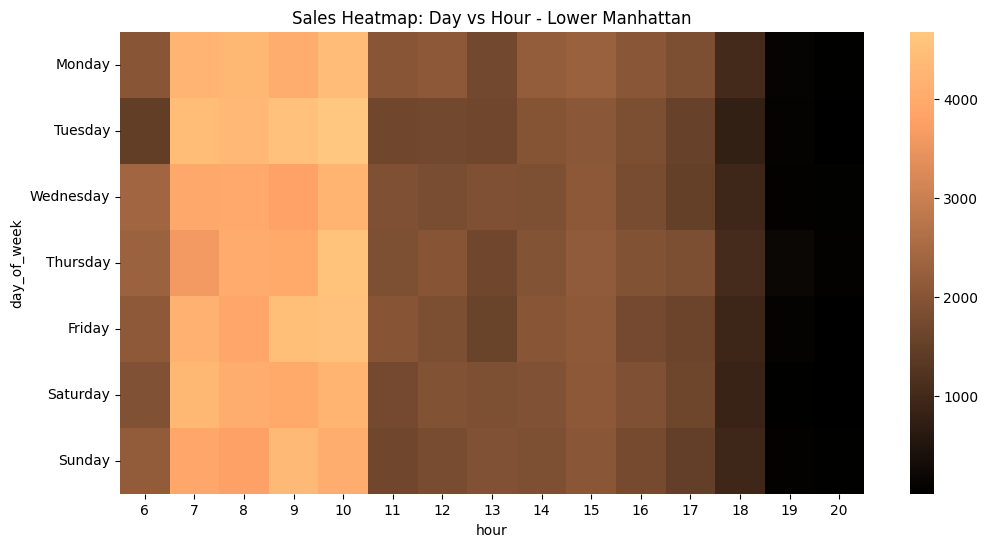

In [46]:
# Heatmap - sales by hour vs day of week... - LOWER MANHATTAN
pivot = lower_manhattan_df.pivot_table(values='revenue', index='day_of_week', columns='hour', aggfunc='sum')
plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap='copper')
plt.title('Sales Heatmap: Day vs Hour - Lower Manhattan')
plt.savefig(f'{save_path}/revenue_heatmap_day_vs_hour_lower_manhattan.png')
plt.show()

Peak sales from 7am to 10am with the busiest days being Tuesday and Friday

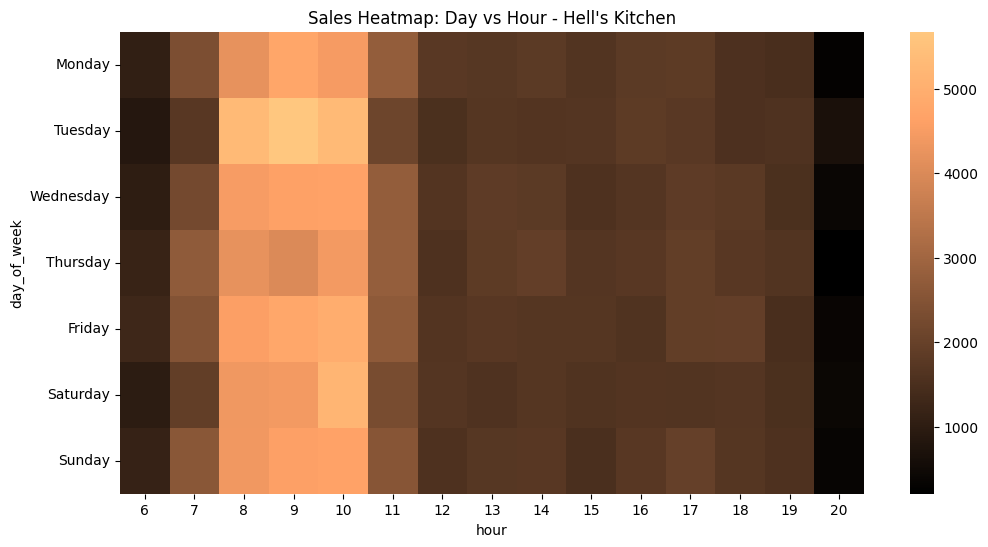

In [47]:
# Heatmap - sales by hour vs day of week... - HELL'S KITCHEN
pivot = hells_kitchen_df.pivot_table(values='revenue', index='day_of_week', columns='hour', aggfunc='sum')
plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap='copper')
plt.title("Sales Heatmap: Day vs Hour - Hell's Kitchen")
plt.savefig(f'{save_path}/revenue_heatmap_day_vs_hour_hells_kitchen.png')
plt.show()

Peak sales from 8am to 10am with the busiest day being Tuesday

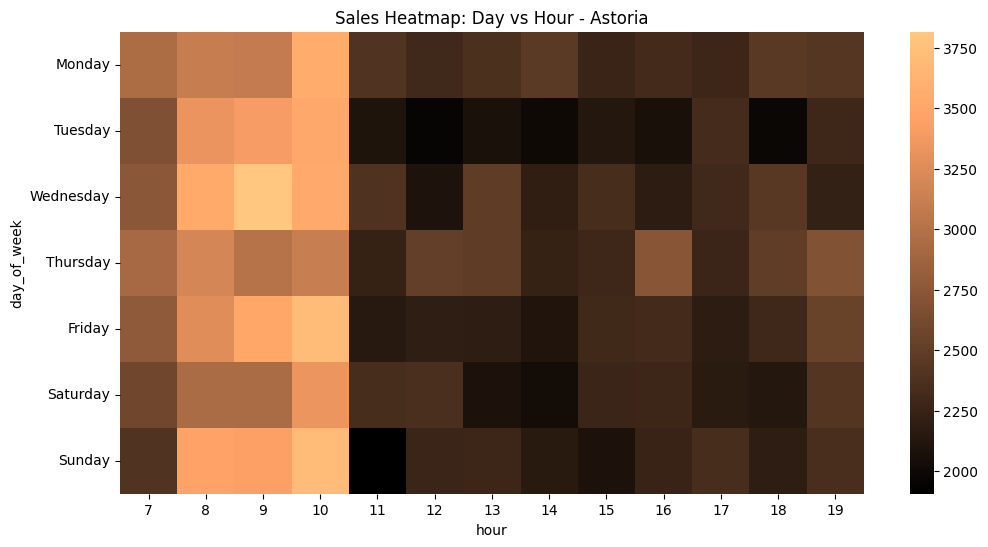

In [48]:
# Heatmap - sales by hour vs day of week... - ASTORIA
pivot = astoria_df.pivot_table(values='revenue', index='day_of_week', columns='hour', aggfunc='sum')
plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap='copper')
plt.title('Sales Heatmap: Day vs Hour - Astoria')
plt.savefig(f'{save_path}/revenue_heatmap_day_vs_hour_astoria.png')
plt.show()

Peak sales from 8am to 10am with the busiest day being Wednesday

## Best selling products and types

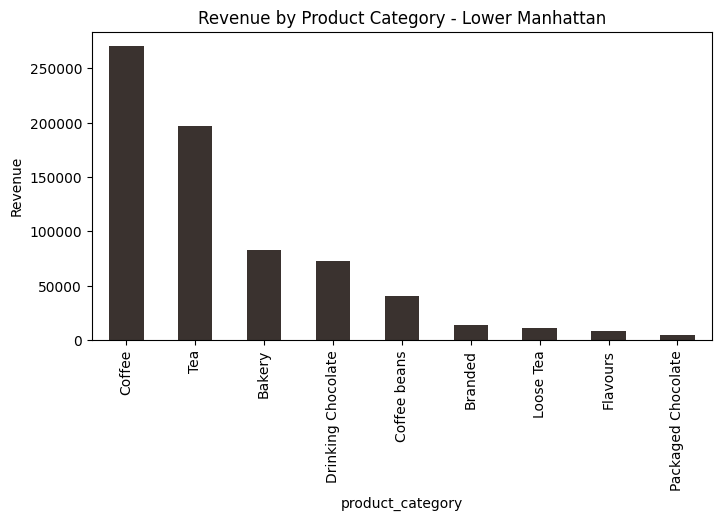

In [49]:
# Products with best sales - LOWER MANHATTAN
product_sales = coffee_df.groupby('product_category')['revenue'].sum().sort_values(ascending=False)
product_sales.plot(kind='bar', figsize=(8,4), color='#3a322f')
plt.title('Revenue by Product Category - Lower Manhattan')
plt.ylabel('Revenue')
plt.savefig(f'{save_path}/revenue_by_product_category_lower_manhattan.png')
plt.show()

Coffee is the highest selling product category followed by tea, then a noticeable decrease in sales for bakery and hot chocolate.

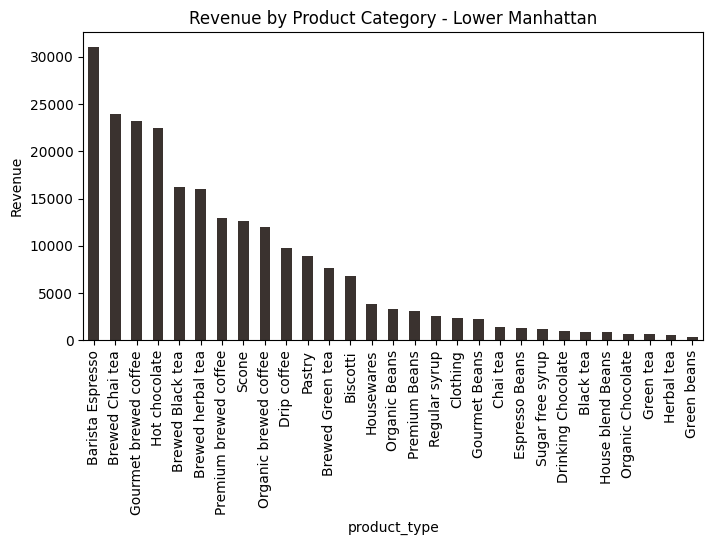

In [50]:
# Products types with best sales - LOWER MANHATTAN
product_sales = lower_manhattan_df.groupby('product_type')['revenue'].sum().sort_values(ascending=False)
product_sales.plot(kind='bar', figsize=(8,4), color='#3a322f')
plt.title('Revenue by Product Category - Lower Manhattan')
plt.ylabel('Revenue')
plt.savefig(f'{save_path}/revenue_by_product_type_lower_manhattan.png')
plt.show()

Espresso products are the best selling product type followed by chai, coffee, and hot chocolate.

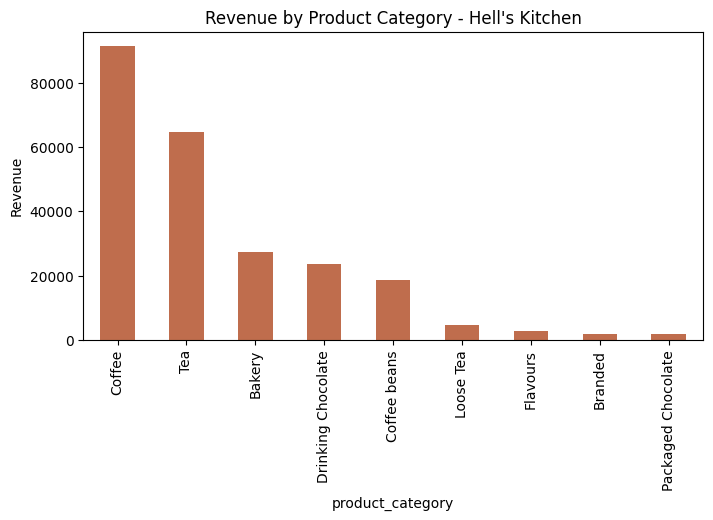

In [51]:
# Products with best sales - HELL'S KITCHEN
product_sales = hells_kitchen_df.groupby('product_category')['revenue'].sum().sort_values(ascending=False)
product_sales.plot(kind='bar', figsize=(8,4), color='#bf6d4d')
plt.title("Revenue by Product Category - Hell's Kitchen")
plt.ylabel('Revenue')
plt.savefig(f'{save_path}/revenue_by_product_category_hells_kitchen.png')
plt.show()

Coffee is the highest selling product category followed by tea, then a noticeable decrease in sales for bakery and hot chocolate.



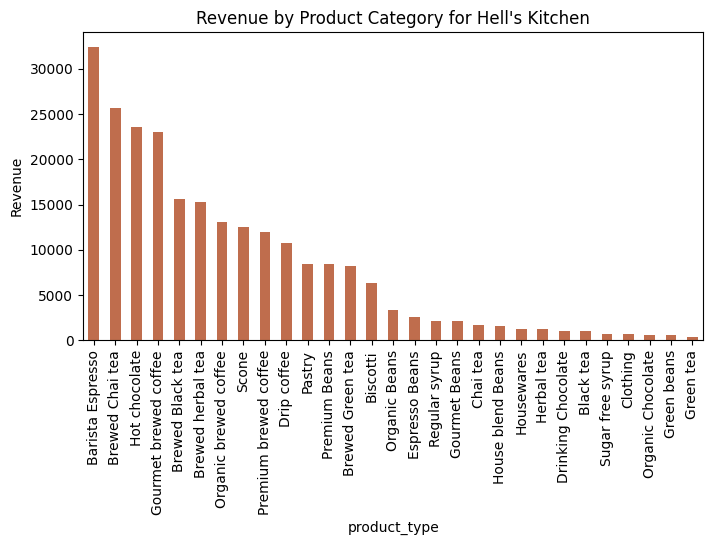

In [52]:
# Products types with best sales - LOWER MANHATTAN
product_sales = hells_kitchen_df.groupby('product_type')['revenue'].sum().sort_values(ascending=False)
product_sales.plot(kind='bar', figsize=(8,4), color='#bf6d4d')
plt.title("Revenue by Product Category for Hell's Kitchen")
plt.ylabel('Revenue')
plt.savefig(f'{save_path}/revenue_by_product_type_hells_kitchen.png')
plt.show()

Espresso products are the best selling product type followed by chai, coffee, and hot chocolate.

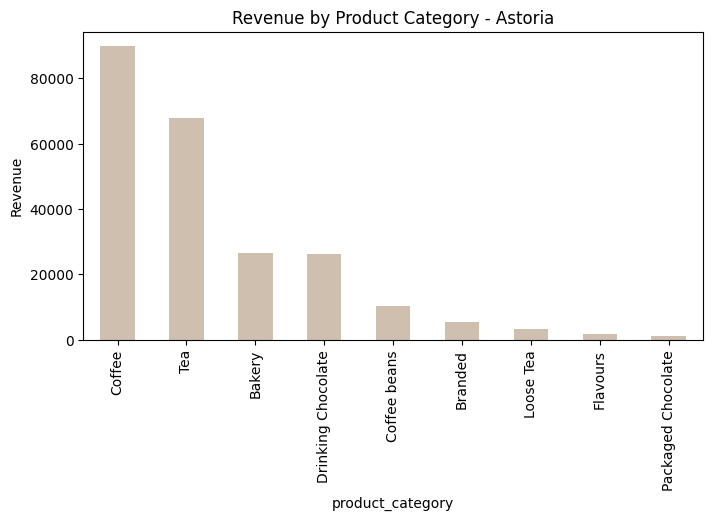

In [53]:
# Products with best sales - ASTORIA
product_sales = astoria_df.groupby('product_category')['revenue'].sum().sort_values(ascending=False)
product_sales.plot(kind='bar', figsize=(8,4), color='#cebfaf')
plt.title('Revenue by Product Category - Astoria')
plt.ylabel('Revenue')
plt.savefig(f'{save_path}/revenue_by_product_category_astoria.png')
plt.show()

Coffee is the highest selling product category followed by tea, then a noticeable decrease in sales for bakery and hot chocolate.

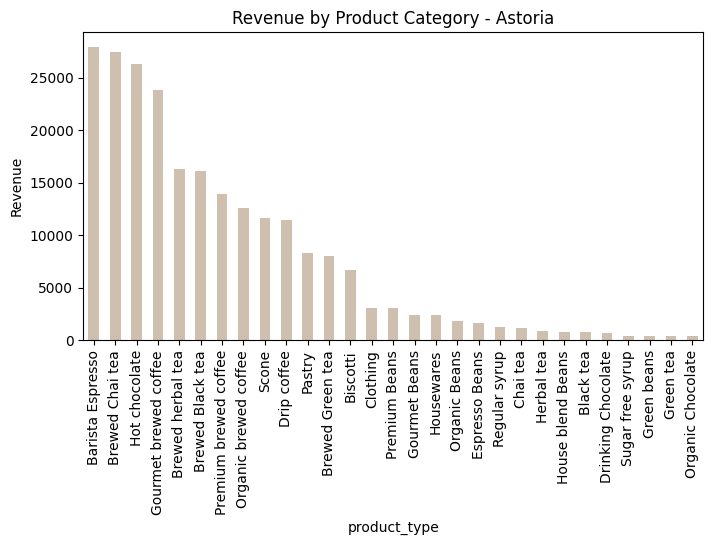

In [54]:
# Products types with best sales - ASTORIA
product_sales = astoria_df.groupby('product_type')['revenue'].sum().sort_values(ascending=False)
product_sales.plot(kind='bar', figsize=(8,4), color='#cebfaf')
plt.title('Revenue by Product Category - Astoria')
plt.ylabel('Revenue')
plt.savefig(f'{save_path}/revenue_by_product_type_astoria.png')
plt.show()

Espresso products are the best selling product type followed by chai, coffee, and hot chocolate.

## Product Trends by Month

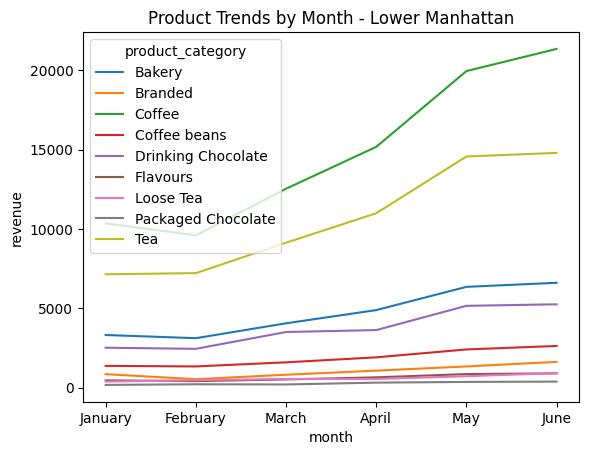

In [55]:
# Investigate any product trends that may vary by month - LOWER MANHATTAN
product_trends = lower_manhattan_df.groupby(['month','product_category'], observed=False)['revenue'].sum().reset_index()
sns.lineplot(data=product_trends, x='month', y='revenue', hue='product_category')
plt.title('Product Trends by Month - Lower Manhattan')
plt.savefig(f'{save_path}/product_trend_by_month_lower_manhattan.png')
plt.show()

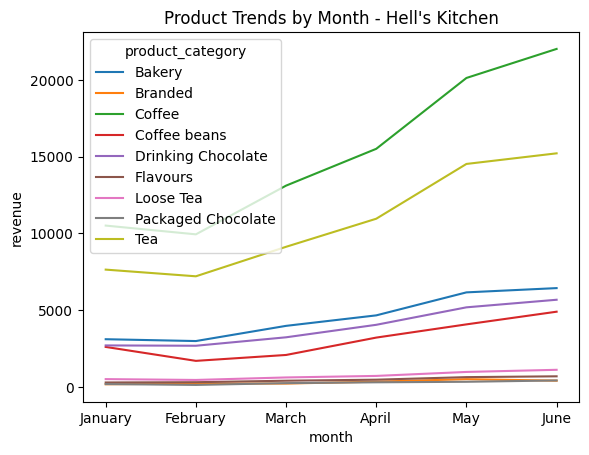

In [56]:
# Investigate any product trends that may vary by month - HELL'S KITCHEN
product_trends = hells_kitchen_df.groupby(['month','product_category'], observed=False)['revenue'].sum().reset_index()
sns.lineplot(data=product_trends, x='month', y='revenue', hue='product_category')
plt.title("Product Trends by Month - Hell's Kitchen")
plt.savefig(f'{save_path}/product_trend_by_month_hells_kitchen.png')
plt.show()

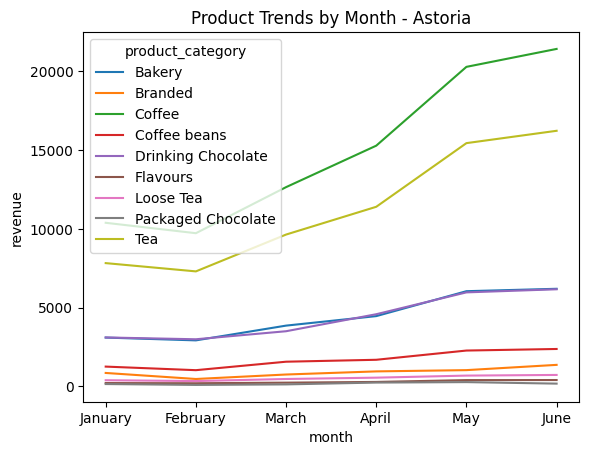

In [57]:
# Investigate any product trends that may vary by month - ASTORIA
product_trends = astoria_df.groupby(['month','product_category'], observed=False)['revenue'].sum().reset_index()
sns.lineplot(data=product_trends, x='month', y='revenue', hue='product_category')
plt.title('Product Trends by Month - Astoria')
plt.savefig(f'{save_path}/product_trend_by_month_astoria.png')
plt.show()

All three locations showed that all products followed a similar trend, increasing as the months go by. Coffee and tea were the two best selling products, noticeably sold more frequently than all other products.

# Summary Statistics

In [59]:
# Basic descriptive statistics (numeric columns)
summary_stats = coffee_df[['transaction_qty', 'unit_price', 'revenue']].describe()
print(summary_stats)

       transaction_qty     unit_price        revenue
count    149116.000000  149116.000000  149116.000000
mean          1.438276       3.382219       4.686367
std           0.542509       2.658723       4.227099
min           1.000000       0.800000       0.800000
25%           1.000000       2.500000       3.000000
50%           1.000000       3.000000       3.750000
75%           2.000000       3.750000       6.000000
max           8.000000      45.000000     360.000000


In [60]:
# Stat summary by product category
summary_by_category = coffee_df.groupby('product_category').agg({
    'transaction_qty': ['sum', 'mean'],
    'unit_price': ['mean', 'max'],
    'revenue': ['sum', 'mean']
}).round(2)

print(summary_by_category)

                   transaction_qty       unit_price           revenue       
                               sum  mean       mean    max        sum   mean
product_category                                                            
Bakery                       23214  1.02       3.55   5.63   82315.64   3.61
Branded                        776  1.04      17.72  28.00   13607.00  18.22
Coffee                       89250  1.53       3.02   4.25  269952.45   4.62
Coffee beans                  1828  1.04      21.02  45.00   40085.25  22.87
Drinking Chocolate           17457  1.52       4.15   4.75   72416.00   6.31
Flavours                     10511  1.55       0.80   0.80    8408.80   1.24
Loose Tea                     1210  1.00       9.27  10.95   11213.60   9.27
Packaged Chocolate             487  1.00       9.05  13.33    4407.64   9.05
Tea                          69737  1.53       2.82   4.00  196405.95   4.32


In [62]:
# Stat summary by location
summary_by_location = coffee_df.groupby('store_location').agg({
    'transaction_qty': 'sum',
    'revenue': 'sum',
    'unit_price': 'mean'
}).round(2).sort_values('revenue', ascending=False)

print(summary_by_location)

                 transaction_qty    revenue  unit_price
store_location                                         
Hell's Kitchen             71737  236511.17        3.39
Astoria                    70991  232243.91        3.38
Lower Manhattan            71742  230057.25        3.37


# Correlation Matrix and Feature Response

                 transaction_qty  unit_price   revenue
transaction_qty         1.000000   -0.123546  0.356231
unit_price             -0.123546    1.000000  0.685550
revenue                 0.356231    0.685550  1.000000


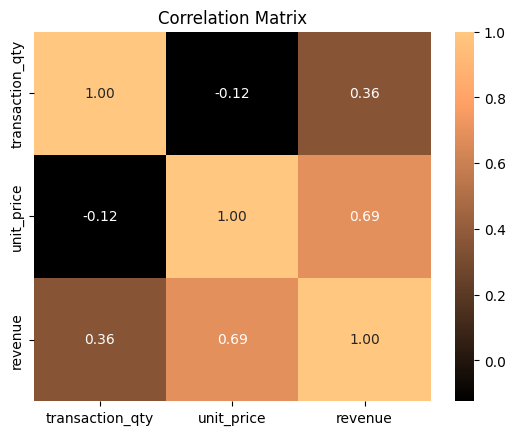

In [64]:
# Compute correlation matrix
coffee_corr = coffee_df[['transaction_qty', 'unit_price', 'revenue']].corr()

# Display as table
print(coffee_corr)

# Create visualization as well
sns.heatmap(coffee_corr, annot=True, cmap='copper', fmt='.2f')
plt.title('Correlation Matrix')
plt.savefig(f'{save_path}/correlation_matrix.png')
plt.show()

In [72]:
# Average revenue by day of week
avg_rev_day = coffee_df.groupby('day_of_week')['revenue'].mean().sort_values(ascending=False)
print(f"Average Revenue in a Day\n {avg_rev_day}\n")

# Average revenue by product category
avg_rev_cat = coffee_df.groupby('product_category')['revenue'].mean().sort_values(ascending=False)
print(f"Average Revenue by Product Category\n {avg_rev_cat}")

Average Revenue in a Day
 day_of_week
Saturday     4.724255
Wednesday    4.707346
Monday       4.697929
Tuesday      4.690875
Friday       4.671352
Sunday       4.661088
Thursday     4.653541
Name: revenue, dtype: float64

Average Revenue by Product Category
 product_category
Coffee beans          22.866657
Branded               18.215529
Loose Tea              9.267438
Packaged Chocolate     9.050595
Drinking Chocolate     6.314615
Coffee                 4.621207
Tea                    4.321458
Bakery                 3.610969
Flavours               1.238409
Name: revenue, dtype: float64


# Store Level Comparisons

In [77]:
# Share of revenue by store
store_revenue = coffee_df.groupby('store_location')['revenue'].sum()
total_revenue = store_revenue.sum()
revenue_share = (store_revenue / total_revenue * 100).round(1)

print(f'Store Revenue: \n{store_revenue}\n')
print(f'Total Revenue: ${total_revenue:.2f}\n')
print(f'Revenue Share Percentage: \n{revenue_share}')

Store Revenue: 
store_location
Astoria            232243.91
Hell's Kitchen     236511.17
Lower Manhattan    230057.25
Name: revenue, dtype: float64

Total Revenue: $698812.33

Revenue Share Percentage: 
store_location
Astoria            33.2
Hell's Kitchen     33.8
Lower Manhattan    32.9
Name: revenue, dtype: float64
